# 07. Post-modeling EDA -- disability strand



## 0. Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed")
OUTPUT_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs")
FIGURE_DIR = OUTPUT_DIR / 'post_eda_figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(OUTPUT_DIR / 'summary_full.csv')
top_activity = pd.read_csv(OUTPUT_DIR / 'top_activity_by_disability_group.csv')

with open(OUTPUT_DIR / 'fitted_models.pkl', 'rb') as f:
    fitted_models = pickle.load(f)
print('fitted models available:', list(fitted_models.keys()))


fitted models available: ['age_overall__Ridge Regression', 'age_overall__Random Forest', 'age_overall__Gradient Boosting', 'dis_overall__Ridge Regression', 'dis_overall__Random Forest', 'dis_overall__Gradient Boosting', 'dis_level__Ridge Regression', 'dis_level__Random Forest', 'dis_level__Gradient Boosting', 'months12__Ridge Regression', 'months12__Random Forest', 'months12__Gradient Boosting', 'days__Ridge Regression', 'days__Random Forest', 'days__Gradient Boosting', 'age_months12__Ridge Regression', 'age_months12__Random Forest', 'age_months12__Gradient Boosting', 'age_days__Ridge Regression', 'age_days__Random Forest', 'age_days__Gradient Boosting', 'age_level__Ridge Regression', 'age_level__Random Forest', 'age_level__Gradient Boosting']


## 1. Model comparison, one panel per task

Covers all 8 tasks (disability strand + age strand).

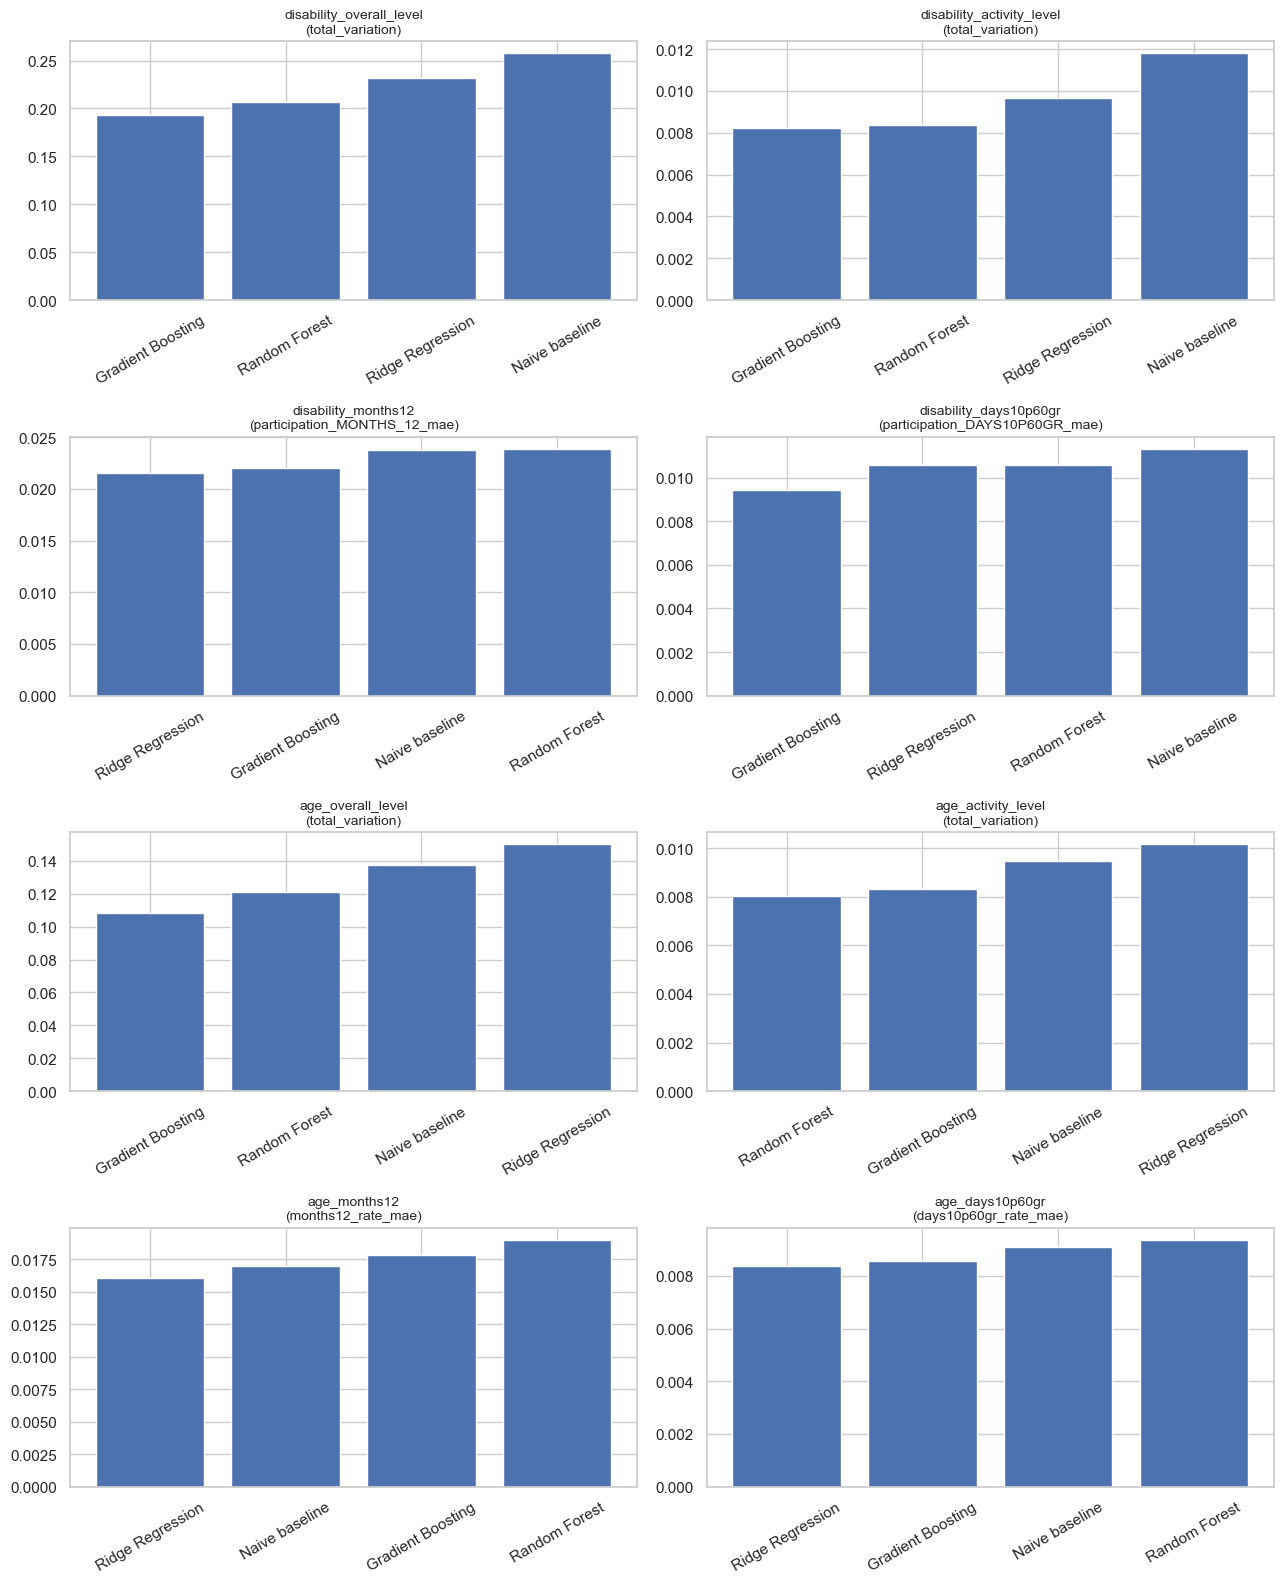

In [7]:
task_primary_metric = {
    'disability_overall_level': 'total_variation',
    'disability_activity_level': 'total_variation',
    'disability_months12': 'participation_MONTHS_12_mae',
    'disability_days10p60gr': 'participation_DAYS10P60GR_mae',
    'age_overall_level': 'total_variation',
    'age_activity_level': 'total_variation',
    'age_months12': 'months12_rate_mae',
    'age_days10p60gr': 'days10p60gr_rate_mae',
}

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for (task, metric), ax in zip(task_primary_metric.items(), axes.ravel()):
    sub = summary[summary['task'] == task].sort_values(metric)
    ax.bar(sub['model'], sub[metric], color='#4C72B0')
    ax.set_title(f'{task}\n({metric})', fontsize=10)
    ax.tick_params(axis='x', labelrotation=30)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_01_model_comparison.png', dpi=150)
plt.show()


R2 of the best model per task (best defined by the primary metric above).
This is where the mae/R2 mismatch on age_months12 shows up.


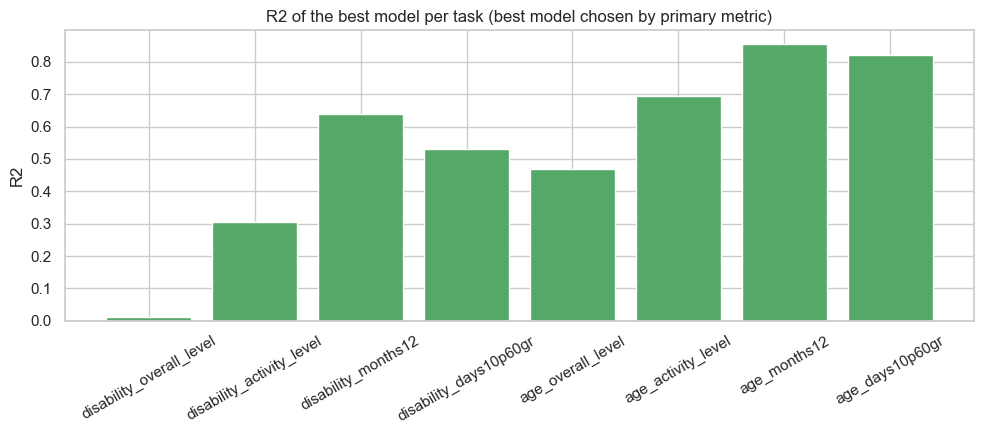

,task,best_model,primary_metric,primary_metric_value,r2
0,disability_overall_level,Gradient Boosting,total_variation,0.193030,0.012852
1,disability_activity_level,Gradient Boosting,total_variation,0.008207,0.305776
2,disability_months12,Ridge Regression,participation_MONTHS_12_mae,0.021582,0.639230
3,disability_days10p60gr,Gradient Boosting,participation_DAYS10P60GR_mae,0.009435,0.531674
4,age_overall_level,Gradient Boosting,total_variation,0.108290,0.468237
5,age_activity_level,Random Forest,total_variation,0.008033,0.693254
6,age_months12,Ridge Regression,months12_rate_mae,0.016035,0.854355
7,age_days10p60gr,Ridge Regression,days10p60gr_rate_mae,0.008373,0.822229


In [8]:
task_r2_column = {
    'disability_overall_level': 'active_rate_r2',
    'disability_activity_level': 'active_rate_r2',
    'disability_months12': 'participation_MONTHS_12_r2',
    'disability_days10p60gr': 'participation_DAYS10P60GR_r2',
    'age_overall_level': 'overall_active_rate_r2',
    'age_activity_level': 'activity_active_rate_r2',
    'age_months12': 'months12_rate_r2',
    'age_days10p60gr': 'days10p60gr_rate_r2',
}

best_model_rows = []
for task, metric in task_primary_metric.items():
    sub = summary[summary['task'] == task].sort_values(metric)
    best_row = sub.iloc[0]
    r2_col = task_r2_column[task]
    best_model_rows.append({
        'task': task,
        'best_model': best_row['model'],
        'primary_metric': metric,
        'primary_metric_value': best_row[metric],
        'r2': best_row[r2_col],
    })

best_model_summary = pd.DataFrame(best_model_rows)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#55A868' if v >= 0 else '#C44E52' for v in best_model_summary['r2']]
ax.bar(best_model_summary['task'], best_model_summary['r2'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('R2 of the best model per task (best model chosen by primary metric)')
ax.set_ylabel('R2')
ax.tick_params(axis='x', labelrotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_01b_best_model_r2_by_task.png', dpi=150)
plt.show()

best_model_summary


## 1c. Unified model comparison table (MAE, RMSE, R2)



In [9]:
def extract_mae_rmse_r2(row):
    if pd.notna(row.get('overall_mae')):
        mae = row['overall_mae']
        rmse = row['overall_rmse']
    else:
        mae_cols = [c for c in row.index if c.endswith('_mae') and c != 'overall_mae']
        rmse_cols = [c for c in row.index if c.endswith('_rmse') and c != 'overall_rmse']
        mae = row[mae_cols].dropna().mean()
        rmse = row[rmse_cols].dropna().mean()

    r2_cols = [c for c in row.index if c.endswith('_r2')]
    r2 = row[r2_cols].dropna().mean()
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'R2': r2})


comparison_table = summary[['task', 'model']].join(summary.apply(extract_mae_rmse_r2, axis=1))
comparison_table = comparison_table.sort_values(['task', 'MAE']).reset_index(drop=True)
comparison_table


,task,model,MAE,RMSE,R2
0,age_activity_level,Random Forest,0.005355,0.024109,0.634454
1,age_activity_level,Gradient Boosting,0.005562,0.024559,0.622144
2,age_activity_level,Naive baseline,0.006328,0.025180,0.555167
3,age_activity_level,Ridge Regression,0.006777,0.030320,0.453917
4,age_days10p60gr,Ridge Regression,0.008373,0.028462,0.822229
5,age_days10p60gr,Gradient Boosting,0.008574,0.028549,0.821145
6,age_days10p60gr,Naive baseline,0.009106,0.032790,0.764047
7,age_days10p60gr,Random Forest,0.009369,0.027198,0.837664
8,age_months12,Ridge Regression,0.016035,0.040759,0.854355
9,age_months12,Naive baseline,0.017008,0.045394,0.819348


### Per-metric pivot tables (task x model)


In [10]:
mae_pivot = comparison_table.pivot(index='task', columns='model', values='MAE')
rmse_pivot = comparison_table.pivot(index='task', columns='model', values='RMSE')
r2_pivot = comparison_table.pivot(index='task', columns='model', values='R2')

print('--- MAE (lower is better) ---')
print(mae_pivot.round(4))
print()
print('--- RMSE (lower is better) ---')
print(rmse_pivot.round(4))
print()
print('--- R2 (higher is better) ---')
print(r2_pivot.round(4))


--- MAE (lower is better) ---
model                      Gradient Boosting  Naive baseline  Random Forest  \
task                                                                          
age_activity_level                    0.0056          0.0063         0.0054   
age_days10p60gr                       0.0086          0.0091         0.0094   
age_months12                          0.0179          0.0170         0.0190   
age_overall_level                     0.0722          0.0918         0.0807   
disability_activity_level             0.0055          0.0079         0.0056   
disability_days10p60gr                0.0094          0.0113         0.0106   
disability_months12                   0.0220          0.0237         0.0239   
disability_overall_level              0.1287          0.1717         0.1377   

model                      Ridge Regression  
task                                         
age_activity_level                   0.0068  
age_days10p60gr                      0.00

### Best model per task, checked against more than one metric

Best-by-MAE and best-by-R2 are found independently for every task.

In [11]:
for task in comparison_table['task'].unique():
    sub = comparison_table[comparison_table['task'] == task]
    best_by_mae = sub.loc[sub['MAE'].idxmin(), 'model']
    best_by_rmse = sub.loc[sub['RMSE'].idxmin(), 'model']
    best_by_r2 = sub.loc[sub['R2'].idxmax(), 'model']

    agree = (best_by_mae == best_by_rmse == best_by_r2)
    flag = '' if agree else '  <-- metrics disagree, needs a written justification'
    print(f'{task}: best by MAE={best_by_mae}, best by RMSE={best_by_rmse}, best by R2={best_by_r2}{flag}')


age_activity_level: best by MAE=Random Forest, best by RMSE=Random Forest, best by R2=Random Forest
age_days10p60gr: best by MAE=Ridge Regression, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
age_months12: best by MAE=Ridge Regression, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
age_overall_level: best by MAE=Gradient Boosting, best by RMSE=Gradient Boosting, best by R2=Gradient Boosting
disability_activity_level: best by MAE=Gradient Boosting, best by RMSE=Gradient Boosting, best by R2=Gradient Boosting
disability_days10p60gr: best by MAE=Gradient Boosting, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
disability_months12: best by MAE=Ridge Regression, best by RMSE=Ridge Regression, best by R2=Ridge Regression
disability_overall_level: best by MAE=Gradient Boosting, best by RMSE=Gradient Boosting, best by

## 2. Prediction error by borough



In [12]:
def add_lag_features(frame, panel_keys, value_cols, lags=(1,), rolling_window=None, covid_years=(5, 6)):
    prepared = frame.sort_values(panel_keys + ['year']).reset_index(drop=True)
    grouped = prepared.groupby(panel_keys, sort=False)
    for column in value_cols:
        for lag in lags:
            prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
        if rolling_window:
            prepared[f'{column}_roll{rolling_window}'] = grouped[column].transform(
                lambda s: s.shift(1).rolling(rolling_window, min_periods=1).mean()
            )
    prepared['time_trend'] = prepared['year'] / prepared['year'].max()
    prepared['is_covid_year'] = prepared['year'].isin(covid_years).astype(int)
    return prepared


def alr_to_shares(values):
    values = np.clip(np.asarray(values, dtype=float), -30, 30)
    exponent = np.exp(values)
    denominator = 1 + exponent.sum(axis=1, keepdims=True)
    return np.column_stack([exponent / denominator, 1 / denominator])


dis_level = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_MEMS7GR_all_years.csv')
dis_level['LA_2023'] = dis_level['LA_2023'].astype('Int64').astype(str)
target_cols = ['inactive_rate', 'fairly_active_rate', 'active_rate']
panel_keys = ['LA_2023', 'disability_group', 'activity']

prepared = add_lag_features(dis_level, panel_keys, target_cols, lags=(1,), rolling_window=2)
lag_cols = [f'{c}_lag1' for c in target_cols] + [f'{c}_roll2' for c in target_cols]
numeric = lag_cols + ['time_trend', 'is_covid_year']
test = prepared[prepared['year'] == 8].dropna(subset=target_cols + lag_cols)

best_model = fitted_models['dis_level__Gradient Boosting']
predicted_shares = alr_to_shares(best_model.predict(test[numeric + panel_keys]))
test = test.copy()
test['predicted_active_rate'] = predicted_shares[:, 2]
test['abs_error'] = (test['active_rate'] - test['predicted_active_rate']).abs()


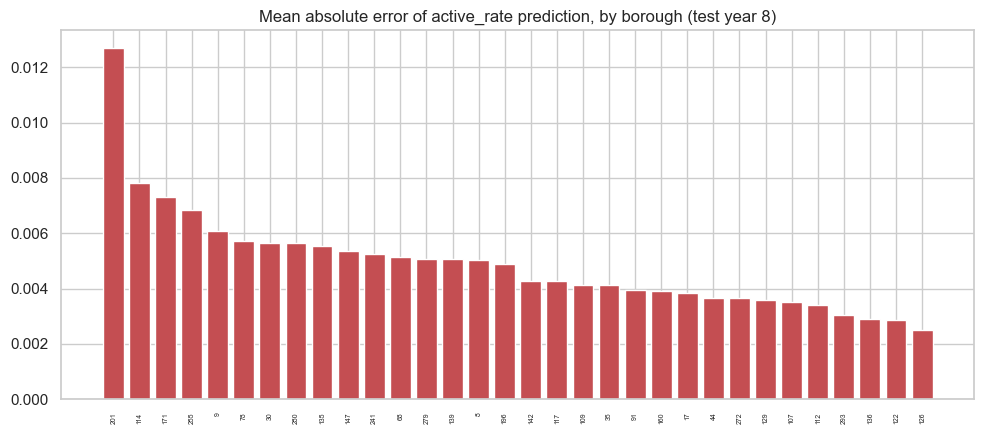

Boroughs with the largest prediction error:
LA_2023
201    0.012703
114    0.007801
171    0.007304
255    0.006826
9      0.006071
Name: abs_error, dtype: float64


In [13]:
error_by_borough = test.groupby('LA_2023')['abs_error'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(error_by_borough.index.astype(str), error_by_borough.values, color='#C44E52')
ax.set_title('Mean absolute error of active_rate prediction, by borough (test year 8)')
ax.tick_params(axis='x', labelrotation=90, labelsize=5)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_02_error_by_borough.png', dpi=150)
plt.show()

print('Boroughs with the largest prediction error:')
print(error_by_borough.head(5))


## 3. Prediction error by disability group


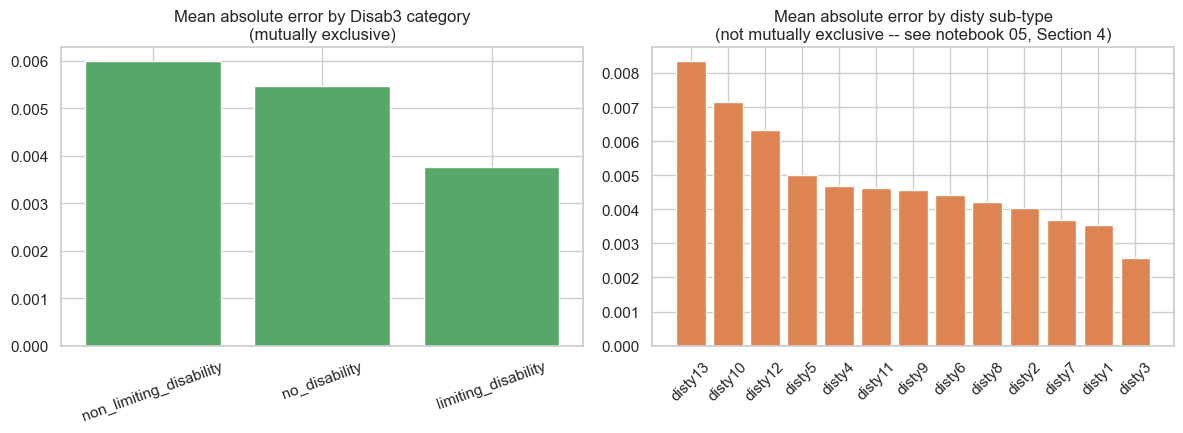

In [14]:
disab3_labels = {'limiting_disability', 'non_limiting_disability', 'no_disability'}
disty_labels = {f'disty{i}' for i in range(1, 14)}

error_by_group = test.groupby('disability_group')['abs_error'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

disab3_error = error_by_group[error_by_group.index.isin(disab3_labels)].sort_values(ascending=False)
axes[0].bar(disab3_error.index, disab3_error.values, color='#55A868')
axes[0].set_title('Mean absolute error by Disab3 category\n(mutually exclusive)')
axes[0].tick_params(axis='x', labelrotation=20)

disty_error = error_by_group[error_by_group.index.isin(disty_labels)].sort_values(ascending=False)
axes[1].bar(disty_error.index, disty_error.values, color='#DD8452')
axes[1].set_title('Mean absolute error by disty sub-type\n(not mutually exclusive -- see notebook 05, Section 4)')
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_03_error_by_disability_group.png', dpi=150)
plt.show()


## 4. Overall-level table vs activity-specific table


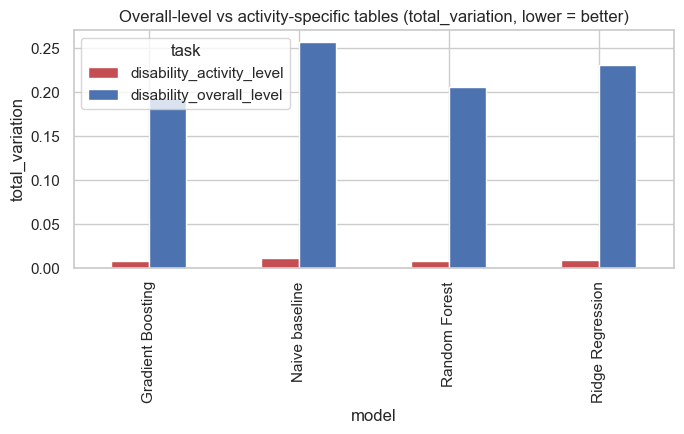

task               disability_activity_level  disability_overall_level
model                                                                 
Gradient Boosting                   0.008207                  0.193030
Naive baseline                      0.011798                  0.257561
Random Forest                       0.008355                  0.206486
Ridge Regression                    0.009662                  0.231541


In [15]:
compare_tasks = summary[summary['task'].isin(['disability_overall_level', 'disability_activity_level'])]
pivot = compare_tasks.pivot(index='model', columns='task', values='total_variation')

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot.plot(kind='bar', ax=ax, color=['#C44E52', '#4C72B0'])
ax.set_title('Overall-level vs activity-specific tables (total_variation, lower = better)')
ax.set_ylabel('total_variation')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_04_overall_vs_activity_level.png', dpi=150)
plt.show()

print(pivot)


## 5. Most preferred activity, distribution across boroughs and groups


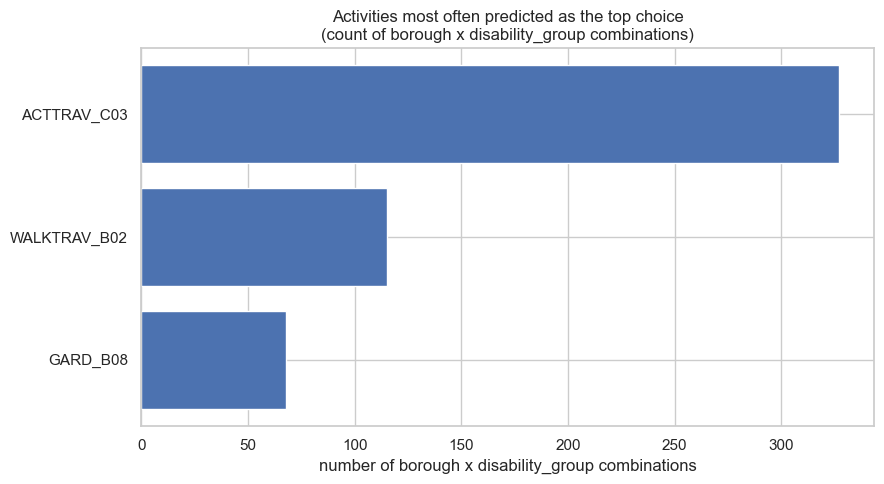

activity
ACTTRAV_C03     327
WALKTRAV_B02    115
GARD_B08         68
Name: count, dtype: int64


In [16]:
activity_win_counts = top_activity['activity'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(activity_win_counts.index[::-1], activity_win_counts.values[::-1], color='#4C72B0')
ax.set_title('Activities most often predicted as the top choice\n(count of borough x disability_group combinations)')
ax.set_xlabel('number of borough x disability_group combinations')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_05_top_activity_distribution.png', dpi=150)
plt.show()

print(activity_win_counts)


## 6. Forecast contrasts (statistical significance)

In [17]:
from scipy import stats

borough_201_errors = test[test['LA_2023'] == '201']['abs_error']
other_borough_errors = test[test['LA_2023'] != '201']['abs_error']

u_statistic, p_value = stats.mannwhitneyu(
    borough_201_errors, other_borough_errors, alternative='greater'
)
print(f'borough 201 vs rest: p={p_value:.4g}, n_201={len(borough_201_errors)}, n_rest={len(other_borough_errors)}')
print('median error, borough 201:', borough_201_errors.median())
print('median error, rest:', other_borough_errors.median())

borough 201 vs rest: p=0.3646, n_201=1875, n_rest=61011
median error, borough 201: 1.0914025114961954e-06
median error, rest: 1.0914025114961954e-06


In [18]:
non_limiting_errors = test[test['disability_group'] == 'non_limiting_disability']['abs_error']
limiting_errors = test[test['disability_group'] == 'limiting_disability']['abs_error']

u_statistic, p_value = stats.mannwhitneyu(
    non_limiting_errors, limiting_errors, alternative='greater'
)
print(f'non_limiting vs limiting: p={p_value:.4g}')
print('median error, non_limiting:', non_limiting_errors.median())
print('median error, limiting:', limiting_errors.median())

non_limiting vs limiting: p=2.96e-07
median error, non_limiting: 1.0914025114961954e-06
median error, limiting: 1.0914025114961954e-06


**Note on the comparison below.** This test compares absolute error on
`active_rate` between the overall-level task and the activity-level task.
The two tasks have different target scales (32 boroughs x 16 groups for the
overall-level table vs the same 512 rows x 125 activities for the
activity-level table), so a direct comparison of absolute errors between
them is not statistically valid. This cell is kept for exploratory
reference only and this
point is recorded as a known methodological limitation for the critical
evaluation chapter.


In [19]:
dis_overall = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_overall_all_years.csv')
dis_overall['LA_2023'] = dis_overall['LA_2023'].astype('Int64').astype(str)
overall_target_cols = ['inactive_rate', 'fairly_active_rate', 'active_rate']

overall_prepared = add_lag_features(dis_overall, ['LA_2023', 'disability_group'], overall_target_cols, lags=(1, 2))
overall_lag_cols = [f'{c}_lag1' for c in overall_target_cols] + [f'{c}_lag2' for c in overall_target_cols]
overall_numeric = overall_lag_cols + ['time_trend', 'is_covid_year']
overall_test = overall_prepared[overall_prepared['year'] == 8].dropna(subset=overall_target_cols + overall_lag_cols)

overall_model = fitted_models['dis_overall__Gradient Boosting']
overall_pred = alr_to_shares(overall_model.predict(overall_test[overall_numeric + ['LA_2023', 'disability_group']]))
overall_test = overall_test.copy()
overall_test['abs_error'] = (overall_test['active_rate'] - overall_pred[:, 2]).abs()

u_statistic, p_value = stats.mannwhitneyu(
    overall_test['abs_error'], test['abs_error'], alternative='greater'
)
print(f'overall-level error vs activity-level error: p={p_value:.4g}')
print('median error, overall-level:', overall_test['abs_error'].median())
print('median error, activity-level:', test['abs_error'].median())


overall-level error vs activity-level error: p=0
median error, overall-level: 0.11916070345158478
median error, activity-level: 1.0914025114961954e-06


## 7. Feature importance by task


In [21]:
from sklearn.multioutput import MultiOutputRegressor


def get_feature_importance(fitted_model, top_n=15):
    preprocess = fitted_model.named_steps['preprocess']
    model = fitted_model.named_steps['model']
    feature_names = preprocess.get_feature_names_out()

    if isinstance(model, MultiOutputRegressor):
        per_target = np.array([est.feature_importances_ for est in model.estimators_])
        importances = per_target.mean(axis=0)
    else:
        importances = model.feature_importances_

    series = pd.Series(importances, index=feature_names)
    return series.sort_values(ascending=False).head(top_n)


def plot_feature_importance(ax, fitted_model, title):
    top = get_feature_importance(fitted_model)
    ax.barh(top.index[::-1], top.values[::-1], color='#4C72B0')
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis='y', labelsize=7)


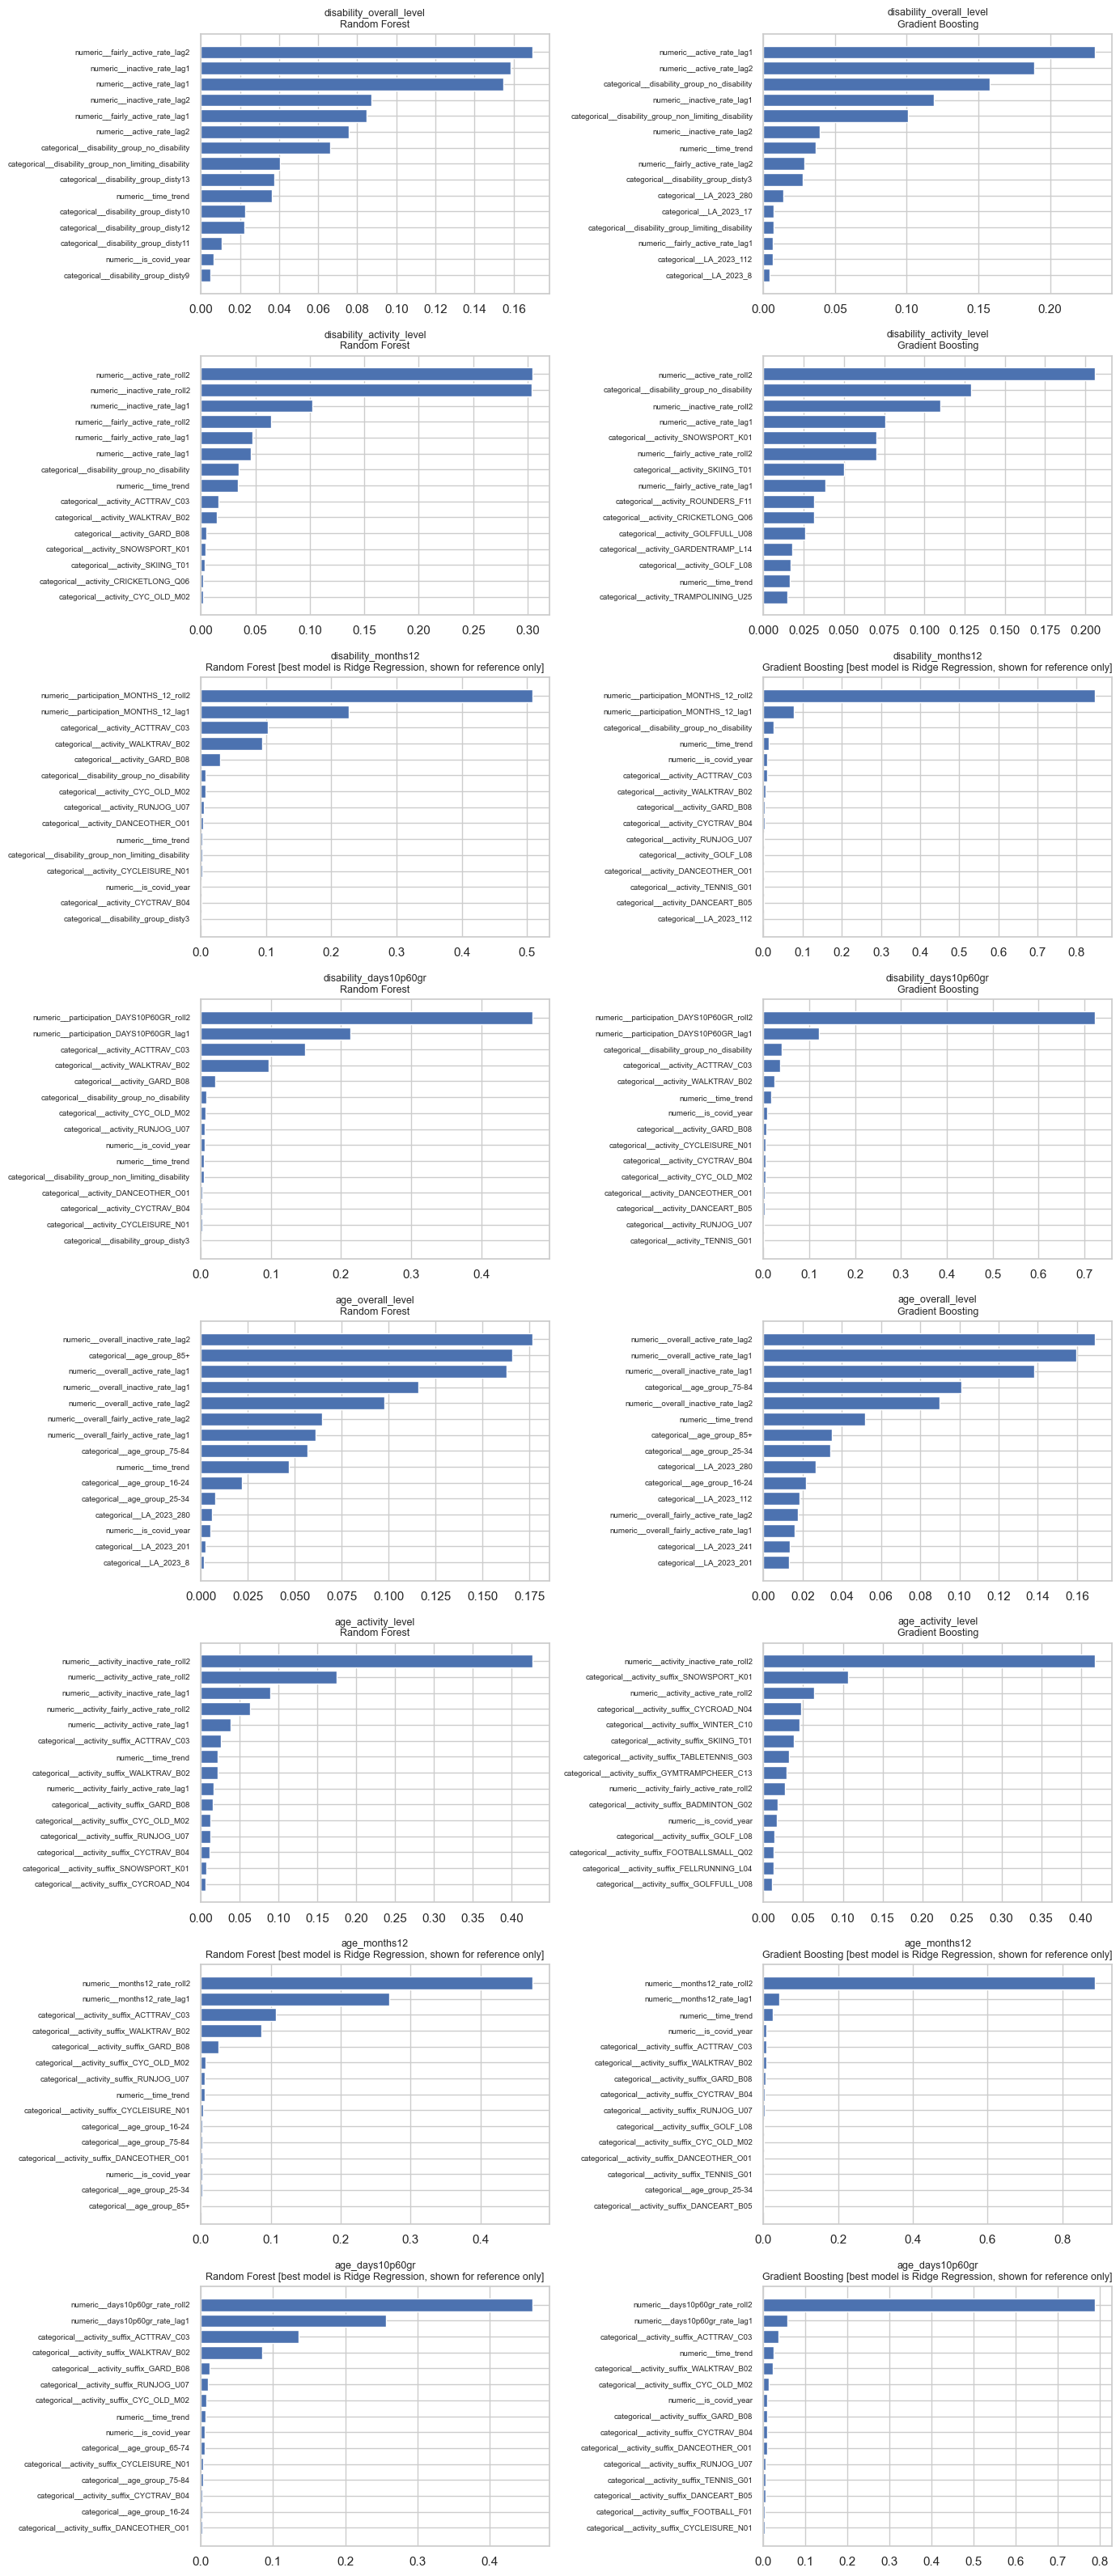

In [22]:
task_info = {
    'disability_overall_level': ('dis_overall', 'Gradient Boosting'),
    'disability_activity_level': ('dis_level', 'Gradient Boosting'),
    'disability_months12': ('months12', 'Ridge Regression'),
    'disability_days10p60gr': ('days', 'Gradient Boosting'),
    'age_overall_level': ('age_overall', 'Gradient Boosting'),
    'age_activity_level': ('age_level', 'Random Forest'),
    'age_months12': ('age_months12', 'Ridge Regression'),
    'age_days10p60gr': ('age_days', 'Ridge Regression'),
}

n_tasks = len(task_info)
fig, axes = plt.subplots(n_tasks, 2, figsize=(14, 4 * n_tasks))

for row, (task_name, (key_prefix, actual_best_model)) in enumerate(task_info.items()):
    ridge_note = ''
    if actual_best_model == 'Ridge Regression':
        ridge_note = ' [best model is Ridge Regression, shown for reference only]'
    for col, model_name in enumerate(['Random Forest', 'Gradient Boosting']):
        ax = axes[row, col]
        fitted_model = fitted_models[f'{key_prefix}__{model_name}']
        title = f'{task_name}\n{model_name}{ridge_note}'
        plot_feature_importance(ax, fitted_model, title)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_06_feature_importance_by_task.png', dpi=150)
plt.show()
